# 1. Import libaries

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Aggregate transactions by customer

In [ ]:
# Load cleaned data
raw_data_cleaned = pd.read_parquet("data/staging/raw_data_cleaned.parquet", engine= "pyarrow")
raw_data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      6000 non-null   str           
 1   gender           6000 non-null   str           
 2   age_group        6000 non-null   str           
 3   city             6000 non-null   str           
 4   signup_date      6000 non-null   datetime64[us]
 5   order_id         6000 non-null   str           
 6   order_date       6000 non-null   datetime64[us]
 7   restaurant_name  6000 non-null   str           
 8   dish_name        6000 non-null   str           
 9   category         6000 non-null   str           
 10  quantity         6000 non-null   int64         
 11  price            6000 non-null   float64       
 12  payment_method   6000 non-null   str           
 13  order_frequency  6000 non-null   int64         
 14  last_order_date  6000 non-null   datetime64[us]
 15

In [ ]:
# Define lastest transaction date
anchor_date = raw_data_cleaned['order_date'].max() + pd.Timedelta(days=1)
anchor_date

Timestamp('2025-08-23 00:00:00')

In [ ]:
rfm_df = raw_data_cleaned.copy()

# Calculate RFM values
rfm_df['recency'] = (anchor_date - rfm_df['last_order_date']).dt.days
rfm_df['frequency'] = rfm_df['order_frequency']
rfm_df['monetary'] = rfm_df['value']
rfm_df.head()

,customer_id,gender,age_group,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,last_order_date,loyalty_points,rating,rating_date,delivery_status,is_churned,value,recency,frequency,monetary
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,...,2025-07-19,238,3,2024-10-14,Cancelled,0,7391.35,35,38,7391.35
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,...,2024-11-25,81,2,2025-08-21,Delayed,0,2868.12,271,24,2868.12
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,...,2025-05-10,82,3,2024-09-19,Delayed,1,1765.02,105,42,1765.02
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,...,2025-07-24,45,2,2025-06-29,Delayed,1,925.20,30,27,925.20
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,...,2024-12-21,418,3,2025-03-06,Cancelled,1,1156.69,245,35,1156.69


In [ ]:
# Retain important features
rfm_df = rfm_df[
    [
    'customer_id',
    'recency',
    'frequency',
    'monetary',
    'loyalty_points',
    'rating',
    'quantity',
    'gender',
    'age_group',
    'city',
    'is_churned'
    ]
]
rfm_df.head()

,customer_id,recency,frequency,monetary,loyalty_points,rating,quantity,gender,age_group,city,is_churned
0,C5663,35,38,7391.35,238,3,5,Male,Adult,Peshawar,0
1,C2831,271,24,2868.12,81,2,3,Male,Adult,Multan,0
2,C2851,105,42,1765.02,82,3,2,Other,Senior,Multan,1
3,C1694,30,27,925.20,45,2,4,Female,Senior,Peshawar,1
4,C4339,245,35,1156.69,418,3,1,Other,Senior,Lahore,1


# 3. Analyze RFM Values

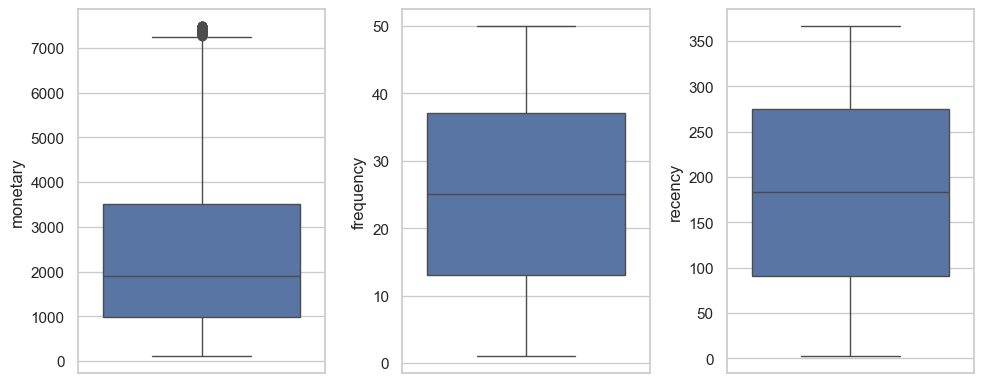

In [17]:
# Detect outliers
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(ncols= 3, figsize= (10, 4))
sns.boxplot(rfm_df['monetary'], ax= axs[0])
sns.boxplot(rfm_df['frequency'], ax= axs[1])
sns.boxplot(rfm_df['recency'], ax= axs[2])
plt.tight_layout()

> R,F,M values spread nicely with no outliers

# 3. Calculate RFM Scores

In [25]:
rfm_df_score = rfm_df.copy()

In [26]:
# Calculate RFM scores using quintiles
rfm_df_score['r_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm_df_score['f_score'] = pd.qcut(rfm_df['frequency'], 5, labels=[1,2,3,4,5]).astype(int)
rfm_df_score['m_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5]).astype(int)

In [27]:
# Get the mean scores of Monetary and Frequency
rfm_df_score['fm_score'] = rfm_df_score[['f_score','m_score']].mean(axis=1)
rfm_df_score.head()

,customer_id,recency,frequency,monetary,loyalty_points,rating,quantity,gender,age_group,city,is_churned,r_score,f_score,m_score,fm_score
0,C5663,35,38,7391.35,238,3,5,Male,Adult,Peshawar,0,5,4,5,4.5
1,C2831,271,24,2868.12,81,2,3,Male,Adult,Multan,0,2,3,4,3.5
2,C2851,105,42,1765.02,82,3,2,Other,Senior,Multan,1,4,5,3,4.0
3,C1694,30,27,925.20,45,2,4,Female,Senior,Peshawar,1,5,3,2,2.5
4,C4339,245,35,1156.69,418,3,1,Other,Senior,Lahore,1,2,4,2,3.0
